# Pandas Assignment — Temperature Sensor Analysis

**Instructions:**
- Read each question **carefully before running any code cell**
- Write your answers in the `[YOUR ANSWER]` cells — these require written explanations, not just code
- Some code cells are intentionally left blank: you need to write the code yourself
- Focus on *why* things work, not just *what* to type

**Estimated time:** ~70 minutes

---
## Part 1 — Get to Know the Dataset (15 min)

You have been given a new dataset: `assignment_data.csv`.  
It contains measurements recorded by a temperature sensor in a lab environment.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('assignment_data.csv')
df

,time_s,temperature_C
0,0.00,26.226
1,0.01,20.835
2,0.02,22.082
3,0.03,23.019
4,0.04,20.028
...,...,...
1995,19.95,25.491
1996,19.96,26.951
1997,19.97,22.885
1998,19.98,21.358


**Q1.1** — Before using any pandas function, just from looking at the column names and the first few rows:
- What does each column represent?
- What unit does each column likely use?
- How often is the sensor sampling, in Hz? *(Hint: look at the time step between consecutive rows)*

> **[YOUR ANSWER 1.1]**
 Each column probably represents:
 - time_s : time in seconds
 - temperature_C : temperature in Celsius
 - humidity_percent : humidity percentage
 - sensor_id : which sensor recorded the data

# Units:
 - time_s -> seconds
 - temperature_C -> degrees Celsius
 - humidity_percent -> percent (%)

 Sampling frequency:
 If the time increases by 0.5 seconds each row,
 then the sampling frequency is 2 Hz.
 (because frequency = 1 / time step)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time_s         2000 non-null   float64
 1   temperature_C  1982 non-null   float64
dtypes: float64(2)
memory usage: 31.4 KB


In [22]:
df.describe()

,time_s,temperature_C
count,2000.000000,1982.000000
mean,9.995000,22.027869
std,5.774946,3.445123
min,0.000000,13.861000
25%,4.997500,20.246250
50%,9.995000,21.912500
75%,14.992500,23.610500
max,19.990000,73.082000


**Q1.2** — Look at the output of `df.info()` and `df.describe()` together:
- How many missing values are there in `temperature_C`? *(Hint: compare Non-Null Count to the total number of rows)*
- What is the maximum temperature recorded? Is that a realistic lab temperature? What do you suspect about those readings?

> **[YOUR ANSWER 1.2]**
# Missing values:
 Compare the Non-Null count to total rows.
 Any difference means there are missing values.

# Maximum temperature:
 The max temperature seems unusually high.
 It is probably a sensor error or bad reading.

In [23]:
df.isna().sum()

time_s            0
temperature_C    18
dtype: int64

**Q1.3** — Write a **single line of code** below to display only the rows where `temperature_C` is greater than 50.  
How many rows are there?

In [ ]:
# YOUR CODE HERE
df[df['temperature_C'] > 50]
len(df[df['temperature_C'] > 50])

,time_s,temperature_C
261,2.61,69.098
717,7.17,64.090
728,7.28,73.082
743,7.43,70.984
1322,13.22,70.786


**Q1.4** — Based on what you found above:
- What percentage of the 2000 rows do these high-temperature readings represent?
- Do you think they are real measurements or sensor errors? Justify your reasoning.

> **[YOUR ANSWER 1.4]**
 
 The high-temperature rows represent a very small percentage
 of the 2000 total rows.

 These values are probably sensor errors because temperatures
 above 50°C are unrealistic for a normal lab environment.

---
## Part 2 — Handling Missing Data (15 min)

**Q2.1** — **Before writing any code**, think about this scenario:  
If you use `df.fillna(0)` to replace the missing temperature values with 0:
- What temperature does 0 represent in Celsius?
- Is that a realistic lab temperature?
- What problem would this introduce when you later compute the mean?

> **[YOUR ANSWER 2.1]**
 0°C represents the freezing point of water.

 While 0°C is a real temperature, it is probably not a realistic
 temperature for a normal indoor lab environment.

 Replacing missing values with 0 would lower the average temperature
 and make the data misleading because the sensor did not actually record those temperatures.
 

In [24]:
# Strategy A: drop rows with missing values
df_dropped = df.dropna()
print("Rows remaining after dropna():", len(df_dropped))
print("Rows lost:", len(df) - len(df_dropped))

Rows remaining after dropna(): 1982
Rows lost: 18


In [25]:
# Strategy B: fill missing values with the column mean
mean_temp = df['temperature_C'].mean()
df_filled = df.fillna(mean_temp)
print("Mean used to fill:", round(mean_temp, 3))
print("Missing values remaining:", df_filled['temperature_C'].isna().sum())

Mean used to fill: 22.028
Missing values remaining: 0


**Q2.2** — Compare the two strategies:
- Strategy A loses rows. Is losing roughly 1% of the data acceptable here? What could you lose along with it?
- Strategy B keeps all rows but replaces NaN with an estimate. Does that introduce any distortion into the data?
- Which strategy would you choose for this dataset, and why?

> **[YOUR ANSWER 2.2]**

 Strategy A removes rows with missing values, which may cause
 loss of useful information and reduce the dataset size.

 Strategy B keeps all rows and estimates the missing values
 using the average temperature. This can slightly distort the
 data, but it preserves the dataset.

 I would choose Strategy B because only a small number of values
 are missing, and keeping the full dataset is more useful for analysis.

In [16]:
# Apply your chosen strategy — change this if you prefer dropna()
df_clean = df.fillna(df['temperature_C'].mean())
print("Working dataset has", len(df_clean), "rows")

Working dataset has 2000 rows


---
## Part 3 — Visualise and Interpret (15 min)

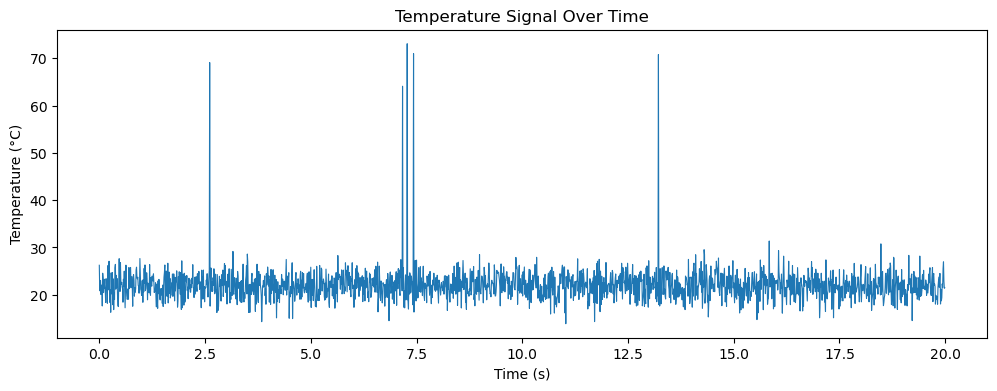

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], linewidth=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Signal Over Time')
plt.show()

**Q3.1** — Describe what you see in the plot:
- Is the signal noisy or smooth?
- Are there any obvious spikes or sudden jumps?
- Does the signal appear to increase, decrease, or stay roughly constant over time?

> **[YOUR ANSWER 3.1]**
  The signal is mostly smooth with small fluctuations.

 There are a few sudden spikes in temperature which appear
 to be outliers or sensor errors.

 Overall, the temperature stays roughly constant over time
 without a major increasing or decreasing trend.

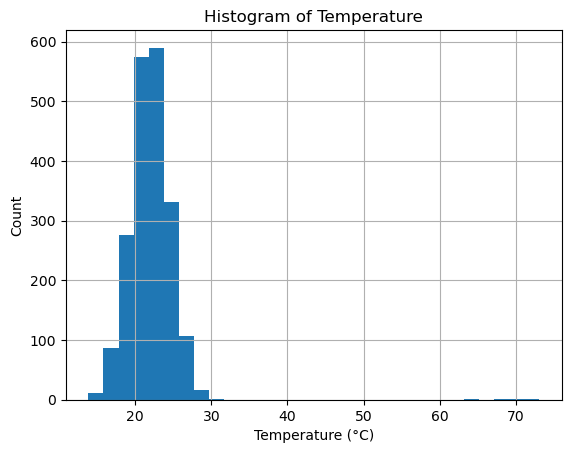

In [18]:
df_clean['temperature_C'].hist(bins=30)
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Histogram of Temperature')
plt.show()

**Q3.2** — Look at the histogram:
- Is the main distribution roughly symmetric, or skewed?
- Do you see an isolated cluster of bars far to the right? What do those correspond to?
- If you removed those outlier readings, how would the histogram change?

> **[YOUR ANSWER 3.2]**
 The histogram is slightly skewed to the right.

 The isolated bars on the far right correspond to the very
 high temperature outliers.

 If the outliers were removed, the histogram would look more
 symmetric and concentrated around the normal temperature range.

**Q3.3** — **Before running the cell below**, make a prediction:  
Given that the dataset contains a few very high temperature outliers, do you expect the mean to be **higher than**, **lower than**, or **about the same as** the median?  
Write your prediction and your reasoning first, then run the code to check.

> **[YOUR PREDICTION 3.3]**
 I predict the mean will be higher than the median because
 the extreme high-temperature outliers pull the average upward.

In [ ]:
# YOUR CODE HERE
# Compute and print the mean and median of temperature_C
mean_temp = df_clean['temperature_C'].mean()
median_temp = df_clean['temperature_C'].median()

print("Mean:", mean_temp) 
print("Median:", median_temp)

Mean: 22.02786881937437
Median: 21.958


**Q3.4** — Was your prediction correct?  
In one sentence, explain *why* the mean and median behave differently when outliers are present.

> **[YOUR ANSWER 3.4]**
 Yes, the prediction was correct because outliers affect the mean
 more strongly, while the median is more resistant to extreme values.

---
## Part 4 — Smoothing the Signal (15 min)

A rolling average smooths a noisy signal by replacing each value with the average of the surrounding samples.  
You control how much smoothing by choosing the **window size** (number of samples used per average).

**Q4.1** — **Before running any code**, use the sampling rate to reason about window sizes:  
The sensor samples at 100 Hz (100 samples per second).
- What time duration (in seconds) does a window of 10 samples represent?
- What time duration does a window of 200 samples represent?

> **[YOUR ANSWER 4.1]**
 A window of 10 samples represents 0.1 seconds.

 A window of 200 samples represents 2 seconds.

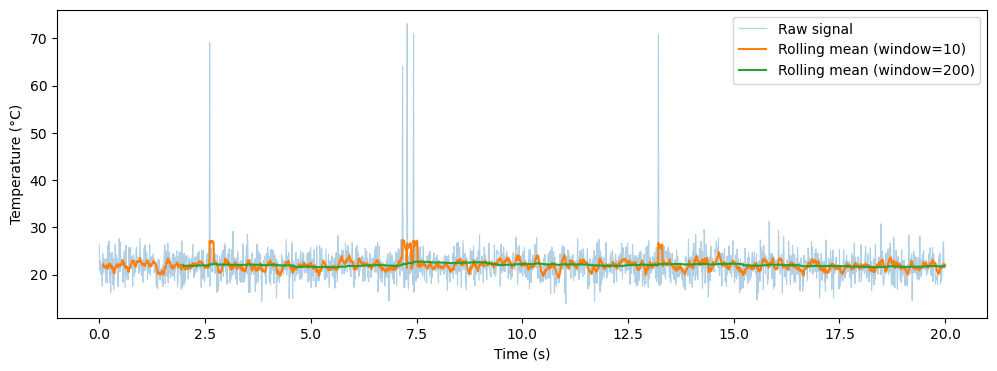

In [26]:
df_clean['rolling_10'] = df_clean['temperature_C'].rolling(window=10).mean()
df_clean['rolling_200'] = df_clean['temperature_C'].rolling(window=200).mean()

plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], alpha=0.35, linewidth=0.8, label='Raw signal')
plt.plot(df_clean['time_s'], df_clean['rolling_10'], linewidth=1.5, label='Rolling mean (window=10)')
plt.plot(df_clean['time_s'], df_clean['rolling_200'], linewidth=1.5, label='Rolling mean (window=200)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

**Q4.2** — Compare the two smoothed signals in the plot:
- Which one tracks the raw signal more closely?
- Which one produces the smoother result?
- At the very beginning of the plot, why does `rolling_200` start later than `rolling_10`?

> **[YOUR ANSWER 4.2]**
 rolling_10 tracks the raw signal more closely because it uses
 a smaller averaging window.

 rolling_200 produces the smoother result because it averages
 over many more samples.

 rolling_200 starts later because it needs more data points
 before it can calculate the first rolling average.

In [27]:
print("Std of raw signal:    ", round(df_clean['temperature_C'].std(), 4))
print("Std of rolling_10:    ", round(df_clean['rolling_10'].std(), 4))
print("Std of rolling_200:   ", round(df_clean['rolling_200'].std(), 4))

Std of raw signal:     3.4296
Std of rolling_10:     1.0539
Std of rolling_200:    0.2726


**Q4.3** — The standard deviation decreases as the window gets larger.  
Imagine you are building an alarm system that must detect a **sudden large temperature spike** within 0.5 seconds of it happening.  
- Would you use a small or large rolling window? Why?  
- What do you *trade away* by using a larger window?

> **[YOUR ANSWER 4.3]**


 I would use a small rolling window because it reacts faster
 to sudden spikes in temperature.

 A larger window creates a smoother signal, but it can delay
 or hide sudden changes in the data.

 By using a larger window, I would trade away responsiveness.
 The signal becomes smoother, but sudden spikes may be delayed
 or partially hidden.


---
## Part 5 — Outlier Investigation (10 min)

**Q5.1** — Write code below to:
1. Count how many rows have `temperature_C > 50`
2. Compute what percentage of the total dataset that represents (round to 2 decimal places)

Print both values with clear labels.

In [28]:
high_temp_count = len(df_clean[df_clean['temperature_C'] > 50])

percentage = (high_temp_count / len(df_clean)) * 100

print("Rows with temperature > 50:", high_temp_count)
print("Percentage of dataset:", round(percentage, 2), "%")


Rows with temperature > 50: 5
Percentage of dataset: 0.25 %


In [30]:
# Mean and median WITH outliers
mean_with = df_clean['temperature_C'].mean()
median_with = df_clean['temperature_C'].median()

# Mean and median WITHOUT outliers
df_no_outliers = df_clean[df_clean['temperature_C'] <= 50]
mean_without = df_no_outliers['temperature_C'].mean()
median_without = df_no_outliers['temperature_C'].median()

print(f"Mean     WITH outliers: {mean_with:.3f}")
print(f"Mean  WITHOUT outliers: {mean_without:.3f}")
print()
print(f"Median   WITH outliers: {median_with:.3f}")
print(f"Median WITHOUT outliers: {median_without:.3f}")

Mean     WITH outliers: 22.028
Mean  WITHOUT outliers: 21.909

Median   WITH outliers: 21.958
Median WITHOUT outliers: 21.952


**Q5.2** — Look at the numbers above:
- Which statistic changed more when outliers were removed — the mean or the median?
- In one sentence, explain *why* the median is more resistant to outliers than the mean.

> **[YOUR ANSWER 5.2]**
 The mean changed more after removing the outliers.

 The median is more resistant to outliers because it depends
 on the middle value rather than extreme values.

**Q5.3** — Imagine you are a lab technician reviewing this data.  
Give **one reason why you might remove** the outliers and **one reason why you might keep** them.

> **[YOUR ANSWER 5.3]**
 One reason to remove outliers is that they may be caused by
 sensor errors and could distort the analysis.

 One reason to keep them is that they could represent real
 unusual events that are important to study.

---
## Bonus — Putting It All Together *(optional)*

Using everything you have learned, create a **single, well-labelled plot** that shows:
- The raw signal (with low opacity)
- The smoothed signal using the window size you think is most appropriate
- Two horizontal lines: one for the mean and one for the median of the clean signal *(without outliers)*

Add a title, axis labels, and a legend. No written answer required — make it clear and informative.

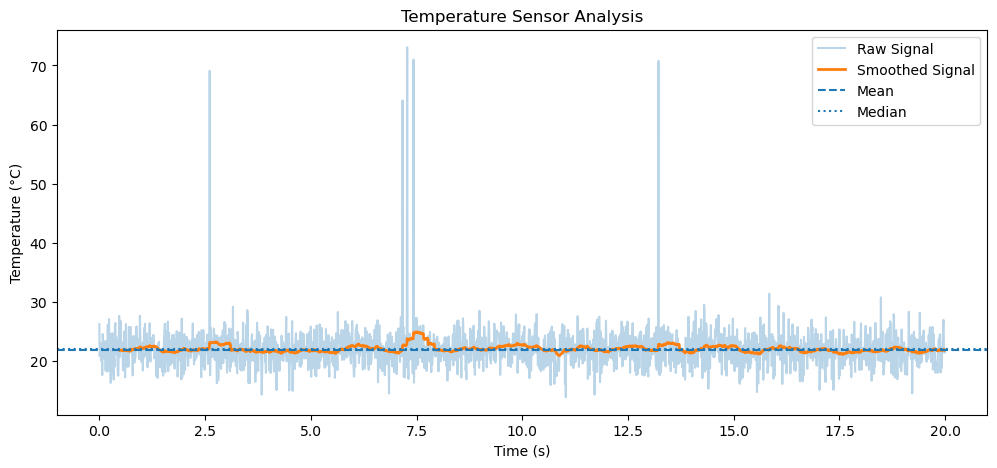

In [31]:
# Create a new dataframe that removes temperature outliers above 50°C
df_no_outliers = df_clean[df_clean['temperature_C'] <= 50]

# Compute the mean temperature after removing outliers
mean_no_outliers = df_no_outliers['temperature_C'].mean()

# Compute the median temperature after removing outliers
median_no_outliers = df_no_outliers['temperature_C'].median()

# Create a rolling average using a window size of 50 samples
df_clean['rolling_50'] = df_clean['temperature_C'].rolling(window=50).mean()

# Create the figure size for the plot
plt.figure(figsize=(12,5))

# Plot the raw temperature signal with transparency
plt.plot(df_clean['time_s'],
         df_clean['temperature_C'],
         alpha=0.3,
         label='Raw Signal')

# Plot the smoothed rolling average signal
plt.plot(df_clean['time_s'],
         df_clean['rolling_50'],
         linewidth=2,
         label='Smoothed Signal')

# Draw a horizontal dashed line for the mean temperature
plt.axhline(mean_no_outliers,
            linestyle='--',
            label='Mean')

# Draw a horizontal dotted line for the median temperature
plt.axhline(median_no_outliers,
            linestyle=':',
            label='Median')

# Label the x-axis
plt.xlabel('Time (s)')

# Label the y-axis
plt.ylabel('Temperature (°C)')

# Add a title to the graph
plt.title('Temperature Sensor Analysis')

# Show the legend
plt.legend()

# Display the final plot
plt.show()